# Exercise 1
# a

In [1]:
import numpy as np

# ----- Discount factor -----
gamma = 0.99   # same as alpha in the text

# ----- Grid definition -----
# W = white, G = green, R = red, V = violet, X = grey (obstacle, not allowed)
grid = [
    ['W', 'G', 'W', 'R', 'V'],
    ['W', 'X', 'G', 'W', 'G'],
    ['W', 'R', 'X', 'W', 'W'],
    ['G', 'W', 'W', 'R', 'V'],
]

n_rows, n_cols = len(grid), len(grid[0])

# ----- Instantaneous cost for each color -----
cost_map = {
    'V': -1.0,   # violet cell
    'W':  0.0,   # white cell
    'G':  1.0,   # green cell
    'R': 10.0,   # red cell
    # 'X' has no cost, because it is not a valid state
}

# ----- List of all valid states (non-grey cells) -----
# We will represent a state as a pair (row, col)
states = []
for r in range(n_rows):
    for c in range(n_cols):
        if grid[r][c] != 'X':   # skip obstacles
            states.append((r, c))

# Maps between (row, col) and index in the value vector
state_to_idx = {s: i for i, s in enumerate(states)}
idx_to_state = {i: s for s, i in state_to_idx.items()}

n_states = len(states)
print("Number of states:", n_states)


Number of states: 18


In [2]:
# We use deterministic transitions: move one cell, or stay in place
actions = {
    'up':    (-1,  0),
    'down':  ( 1,  0),
    'left':  ( 0, -1),
    'right': ( 0,  1),
    'stay':  ( 0,  0),
}

def step(state, action):
    """
    Deterministic transition function.
    Given a state (r, c) and an action name, return the next state (r', c').

    If the move would leave the grid or enter a grey cell (obstacle),
    the agent stays in the same state.
    """
    r, c = state
    dr, dc = actions[action]
    r2, c2 = r + dr, c + dc

    # Check boundaries and obstacles
    if not (0 <= r2 < n_rows and 0 <= c2 < n_cols):
        r2, c2 = r, c
    elif grid[r2][c2] == 'X':
        r2, c2 = r, c

    return (r2, c2)

def stage_cost(state):
    """
    Instantaneous cost g(x) for a given state.
    """
    r, c = state
    color = grid[r][c]
    return cost_map[color]   # <-- no underscore here


In [3]:
# ----- Value Iteration -----

# Initialize value function to zero
V = np.zeros(n_states)

# Convergence threshold (max absolute change <= theta)
theta = 1e-6

iteration = 0

while True:
    delta = 0.0
    V_new = V.copy()

    # Update each state
    for i, s in enumerate(states):
        # Compute the minimal cost over all actions
        best_q = float('inf')
        for a in actions.keys():
            s_next = step(s, a)
            j = state_to_idx[s_next]

            # Bellman update for cost minimization
            q_sa = stage_cost(s) + gamma * V[j]

            if q_sa < best_q:
                best_q = q_sa

        V_new[i] = best_q
        delta = max(delta, abs(V_new[i] - V[i]))

    V = V_new
    iteration += 1

    # Check convergence
    if delta < theta:
        break

print("Value Iteration converged after", iteration, "iterations.")
print("Max change in last iteration:", delta)

# Optional: reshape the value function into grid form (for printing)
V_grid = np.full((n_rows, n_cols), np.nan)
for i, (r, c) in enumerate(states):
    V_grid[r, c] = V[i]

print("Value function on the grid:")
print(V_grid)


Value Iteration converged after 1376 iterations.
Max change in last iteration: 9.963056157857864e-07
Value function on the grid:
[[-91.24613716 -92.16781631 -94.10890636 -88.99990137 -99.99990137]
 [-90.3336748           nan -95.05950237 -97.02980137 -97.99990137]
 [-89.43033706 -78.53603271          nan -98.00990137 -98.99990137]
 [-87.53603271 -87.22880137 -88.10990137 -88.99990137 -99.99990137]]


# b

In [4]:
import numpy as np

def evaluate_policy(policy):
    """
    Evaluate a policy μ by solving the linear system:
        (I - gamma * A_mu) * J = g_bar
    where:
        A_mu[i, j] = 1 if next_state(j) is reached deterministically under μ(i)
    """
    A = np.zeros((n_states, n_states))
    g_bar = np.zeros(n_states)

    # Build A_mu and g_bar
    for i, s in enumerate(states):
        a = policy[i]                    # action taken by the policy μ(s)
        s_next = step(s, a)
        j = state_to_idx[s_next]

        A[i, j] = 1.0                    # deterministic transition
        g_bar[i] = stage_cost(s)         # instantaneous cost

    # Solve the linear system (I - gamma*A) * J = g_bar
    I = np.eye(n_states)
    J = np.linalg.solve(I - gamma * A, g_bar)

    return J


In [5]:
# ----- Policy Iteration -----


policy = ['stay' for _ in range(n_states)]

iteration = 0

while True:
    iteration += 1

    # Step 1: Policy evaluation
    J = evaluate_policy(policy)

    # Step 2: Policy improvement
    policy_stable = True
    new_policy = policy.copy()

    for i, s in enumerate(states):
        best_a = None
        best_q = float('inf')

        # Check all possible actions
        for a in actions.keys():
            s_next = step(s, a)
            j = state_to_idx[s_next]
            q_sa = stage_cost(s) + gamma * J[j]

            if q_sa < best_q:
                best_q = q_sa
                best_a = a

        # Update policy if improved
        if best_a != policy[i]:
            policy_stable = False
            new_policy[i] = best_a

    policy = new_policy

    # If policy did not change → converged
    if policy_stable:
        break

print("Policy Iteration converged after", iteration, "iterations.")


policy_grid = np.full((n_rows, n_cols), None, dtype=object)
for i, (r, c) in enumerate(states):
    policy_grid[r, c] = policy[i]

print("Optimal policy on the grid (text form):")
print(policy_grid)


Policy Iteration converged after 7 iterations.
Optimal policy on the grid (text form):
[['right' 'right' 'down' 'right' 'up']
 ['up' None 'right' 'down' 'up']
 ['up' 'left' None 'right' 'down']
 ['up' 'right' 'right' 'right' 'down']]


# c

For this grid-world problem, both value iteration and policy iteration converge to the same optimal solution, but they behave differently in terms of convergence speed and computational cost.

In our implementation, value iteration required 1376 iterations to reach the stopping condition where the maximum change in the value function between two consecutive iterations is below 1e-6. Each iteration is relatively cheap: for every state, the algorithm performs a Bellman update by checking all possible actions, computing the immediate cost plus the discounted value of the next state, and taking the minimum. The computational cost of one sweep is therefore proportional to the number of states times the number of actions. However, many iterations are needed because the value information propagates slowly through the grid.

Policy iteration, on the other hand, converged in only 7 iterations. Each iteration has two steps. First, in the policy evaluation step, we compute the value function of the current policy by solving a linear system of equations. Second, in the policy improvement step, we update the policy by selecting the action that minimizes the one-step cost plus the discounted value of the next state. Solving the linear system is more expensive than a single sweep of value iteration, but the number of outer iterations is much smaller because each evaluation step gives an exact value function for the current policy.

Overall, for this small grid world, policy iteration is faster in terms of total work because it converges in very few iterations, even though each iteration is computationally heavier. Value iteration is simpler and cheaper per iteration, but requires many updates to reach convergence. For larger state spaces, the comparison may change: policy iteration can become expensive due to solving large linear systems, while value iteration remains easy to implement but may still require many iterations to achieve a small error tolerance.


# Exercise 2

In [7]:
# Because I'm using NYU HPC, I can only use the following four codes each time, for which I sincerely apologize. 
# You can start from [5].

In [8]:
import sys, os, shutil, matplotlib as mpl
from pathlib import Path
import platform

print("Python exec:", sys.executable)
print("Platform:", platform.platform())
print("Matplotlib version:", mpl.__version__)

# Current environment path
env_bin = Path(sys.executable).parent
print("Environment bin path:", env_bin)

# Check if ffmpeg exists
ffmpeg_path = env_bin / "ffmpeg"
print("Expected ffmpeg path:", ffmpeg_path)
print("Exists?", ffmpeg_path.exists())

Python exec: /scratch/ww2781/conda_envs/reinforcement/bin/python
Platform: Linux-5.14.0-284.86.1.el9_2.x86_64-x86_64-with-glibc2.34
Matplotlib version: 3.10.6
Environment bin path: /scratch/ww2781/conda_envs/reinforcement/bin
Expected ffmpeg path: /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg
Exists? True


In [9]:
# Add reinforcement/bin to PATH
env_bin_str = str(Path(sys.executable).parent)
os.environ["PATH"] = env_bin_str + os.pathsep + os.environ.get("PATH", "")
print("PATH updated. ffmpeg found by shutil.which?:", shutil.which("ffmpeg"))

# Explicitly setting Matplotlib's animation writer
ff_path = shutil.which("ffmpeg") or str(env_bin / "ffmpeg")
mpl.rcParams["animation.writer"] = "ffmpeg"
mpl.rcParams["animation.ffmpeg_path"] = ff_path

print("Matplotlib animation.writer =", mpl.rcParams["animation.writer"])
print("Matplotlib animation.ffmpeg_path =", mpl.rcParams["animation.ffmpeg_path"])


PATH updated. ffmpeg found by shutil.which?: /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg
Matplotlib animation.writer = ffmpeg
Matplotlib animation.ffmpeg_path = /scratch/ww2781/conda_envs/reinforcement/bin/ffmpeg


In [10]:
from matplotlib.animation import writers
print("writers.is_available('ffmpeg') =", writers.is_available("ffmpeg"))


writers.is_available('ffmpeg') = True


In [11]:
# Cell 1: a few packages we need to import
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.animation as animation
import IPython 

import torch

import pendulum

In [12]:
# Cell 2: define Q-network (as in the assignment) and basic parameters

import torch.nn as nn

np.random.seed(2)
torch.manual_seed(2)


## we define the neural network to be used for Q-learning
## 2 hidden layers with 64 nodes
## 2 inputs (state)
## 3 outputs for the 3 possible controls
D_in, H, D_out = 2, 64, 3

q_function = nn.Sequential(
    nn.Linear(D_in, H),
    nn.ReLU(),
    nn.Linear(H, H),
    nn.ReLU(),
    nn.Linear(H, H),
    nn.ReLU(),
    nn.Linear(H, D_out)
)

## we initialize the network parameters to 0
# with torch.no_grad():
#     for p in q_function.parameters():
#         p.zero_()
for params in q_function.parameters():
    params = torch.zeros_like(params)
    
### possible controls
possible_controls = np.array([-5., 0., 5.])

# Hyperparameters for Q-learning
gamma = 0.99          # discount factor (alpha in the statement)
epsilon = 0.1         # epsilon for epsilon-greedy exploration
episode_length = 100  # number of time steps per episode
num_episodes = 1000   # total number of training episodes (you can adjust this)

# Optimizer and loss function for SGD on the neural network
learning_rate = 0.1
optimizer = torch.optim.SGD(q_function.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()


In [13]:
# Cell 3: cost function and epsilon-greedy policy

def stage_cost(x, u):
    """
    Compute the instantaneous cost g(x, v, u).

    Parameters
    ----------
    x : numpy array of shape (2,)
        Current state [theta, velocity].
    u : float
        Control input.

    Returns
    -------
    float
        Instantaneous cost g(x, u).
    """
    theta = x[0]
    v = x[1]
    cost = 0.01 * (1.0 - np.cos(theta - np.pi))**2 \
           + 0.0001 * (v**2) \
           + 0.000001 * (u**2)
    return cost


def select_action_epsilon_greedy(x, epsilon):
    """
    Select an action index using an epsilon-greedy policy
    with respect to the current Q-network.

    Parameters
    ----------
    x : numpy array of shape (2,)
        Current state.
    epsilon : float
        Exploration probability.

    Returns
    -------
    int
        Index of the chosen action in {0, 1, 2}.
    """
    # Exploration: choose a random action with probability epsilon
    if np.random.rand() < epsilon:
        action_index = np.random.randint(len(possible_controls))
        return action_index

    # Exploitation: choose the action with minimal estimated Q-value
    with torch.no_grad():
        state_tensor = torch.from_numpy(x).float().unsqueeze(0)  # shape (1, 2)
        q_values = q_function(state_tensor)                      # shape (1, 3)
        action_index = torch.argmin(q_values, dim=1).item()
    return action_index


In [14]:
# Cell 4: main Q-learning training loop

cost_per_episode = []  # store the total cost of each episode

for episode in range(num_episodes):
    # Initialize state x0 = [0, 0]
    x = np.array([0.0, 0.0])
    total_cost = 0.0

    for t in range(episode_length):
        # 1) Choose action using epsilon-greedy policy
        action_idx = select_action_epsilon_greedy(x, epsilon)
        u = possible_controls[action_idx]

        # 2) Apply action to the environment and get next state
        x_next = pendulum.step(x, u)

        # 3) Compute instantaneous cost g(x, u)
        g = stage_cost(x, u)
        total_cost += g

        # 4) Compute target y = g(x,u) + gamma * min_a Q(x_next, a)
        with torch.no_grad():
            next_state_tensor = torch.from_numpy(x_next).float().unsqueeze(0)  # (1, 2)
            q_next = q_function(next_state_tensor)                             # (1, 3)
            min_q_next, _ = torch.min(q_next, dim=1)                           # (1,)
            y = g + gamma * min_q_next.item()                                  # scalar

        # 5) Compute current Q(x, u) from the network
        state_tensor = torch.from_numpy(x).float().unsqueeze(0)  # (1, 2)
        q_values = q_function(state_tensor)                      # (1, 3)
        q_value_for_u = q_values[0, action_idx]                  # scalar

        # 6) Perform one SGD step to minimize (Q(x,u) - y)^2
        target_tensor = torch.tensor([y], dtype=torch.float32)   # (1,)
        loss = loss_fn(q_value_for_u.unsqueeze(0), target_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 7) Move to the next state
        x = x_next

    cost_per_episode.append(total_cost)

    # Optional: print progress every 100 episodes
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1}/{num_episodes}, total cost = {total_cost:.3f}")


Episode 100/1000, total cost = 2.259
Episode 200/1000, total cost = 1.594
Episode 300/1000, total cost = 1.478
Episode 400/1000, total cost = 1.597
Episode 500/1000, total cost = 1.286
Episode 600/1000, total cost = 0.812
Episode 700/1000, total cost = 0.563
Episode 800/1000, total cost = 0.787
Episode 900/1000, total cost = 1.148
Episode 1000/1000, total cost = 0.995


In [15]:
# Cell 5: test the learned controller without external pushes
x0 = np.zeros((2,1))
def controller(x):
    u_pred = torch.argmin(q_function(torch.as_tensor(x, dtype=torch.float).unsqueeze(0))).item()
    u = possible_controls[u_pred]
    return u
    
pendulum.animate_robot(x0,controller,push=False, save_movie=True)
if os.path.exists('pendulum_movie.mp4'):
    os.rename('pendulum_movie.mp4', 'pendulum_no_push.mp4')
    print("pendulum_no_push.mp4")

Your browser does not support the video tag.

pendulum_no_push.mp4


In [16]:
# Cell 6: test the learned controller with external pushes
x0 = np.zeros((2,1))
def controller(x):
    u_pred = torch.argmin(q_function(torch.as_tensor(x, dtype=torch.float).unsqueeze(0))).item()
    u = possible_controls[u_pred]
    return u
    
pendulum.animate_robot(x0,controller,push=True, save_movie=True)
if os.path.exists('pendulum_movie.mp4'):
    os.rename('pendulum_movie.mp4', 'pendulum_push.mp4')
    print("pendulum_push.mp4")

Your browser does not support the video tag.

pendulum_push.mp4


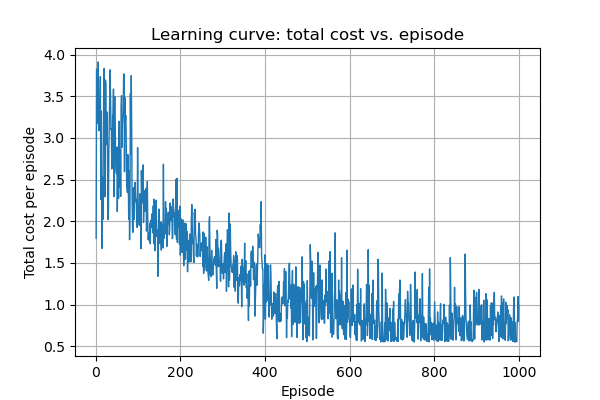

In [17]:
# Cell 7: plot total cost per episode

episodes = np.arange(1, len(cost_per_episode) + 1)

plt.figure(figsize=(6, 4))
plt.plot(episodes, cost_per_episode, linewidth=1)
plt.xlabel("Episode")
plt.ylabel("Total cost per episode")
plt.title("Learning curve: total cost vs. episode")
plt.grid(True)

# Save figure
plt.savefig("learning_curve.png", dpi=300, bbox_inches="tight")

plt.show()


In [18]:
# Cell 8: compute the learned value function and policy on a 2D grid

# Define the range of pendulum position (theta) and velocity v
# theta is modulo 2*pi, and the dynamics clips velocity to [-6, 6]
theta_min, theta_max = 0.0, 2.0 * np.pi
v_min, v_max = -6.0, 6.0

# Resolution of the grid (you can change these numbers)
num_theta = 80   # number of points along theta
num_v = 80       # number of points along velocity

theta_values = np.linspace(theta_min, theta_max, num_theta)
v_values = np.linspace(v_min, v_max, num_v)

# Create 2D meshgrid
Theta_grid, V_grid = np.meshgrid(theta_values, v_values)  # shape (num_v, num_theta)

# Flatten the grid to a list of states (N, 2) for batch processing in the network
states = np.stack([Theta_grid.ravel(), V_grid.ravel()], axis=1)  # (N, 2)

# Evaluate Q-values for all states
with torch.no_grad():
    state_tensor = torch.from_numpy(states).float()          # (N, 2)
    q_vals = q_function(state_tensor)                        # (N, 3)
    min_q_vals, best_action_idx = torch.min(q_vals, dim=1)   # each is (N,)

# Reshape results back to 2D grids
value_grid = min_q_vals.cpu().numpy().reshape(Theta_grid.shape)             # (num_v, num_theta)
policy_index_grid = best_action_idx.cpu().numpy().reshape(Theta_grid.shape) # (num_v, num_theta)


policy_u_grid = possible_controls[policy_index_grid]  # same shape as Theta_grid


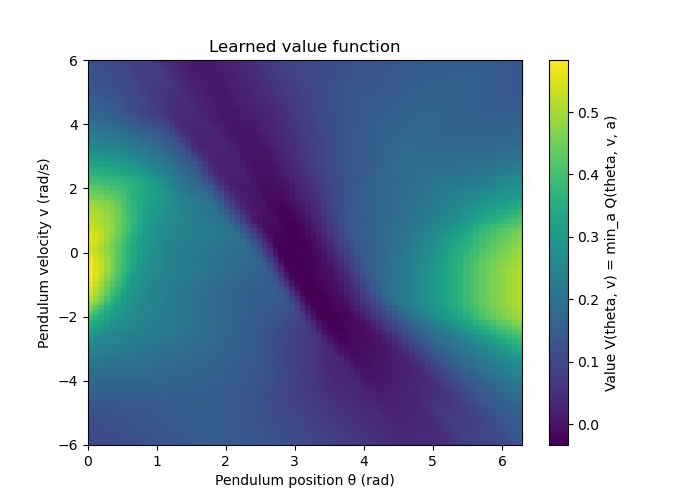

In [19]:
# Cell 9: plot the learned value function V(theta, v)

plt.figure(figsize=(7, 5))

# imshow expects [x_min, x_max, y_min, y_max] as "extent"
extent = [theta_min, theta_max, v_min, v_max]

im = plt.imshow(
    value_grid,
    origin="lower",     # so that smaller v is at the bottom
    extent=extent,
    aspect="auto"       # so the plot is not distorted
)

plt.colorbar(im, label="Value V(theta, v) = min_a Q(theta, v, a)")
plt.xlabel("Pendulum position θ (rad)")
plt.ylabel("Pendulum velocity v (rad/s)")
plt.title("Learned value function")


# Save figure
plt.savefig("value_function.png", dpi=300, bbox_inches="tight")
plt.show()


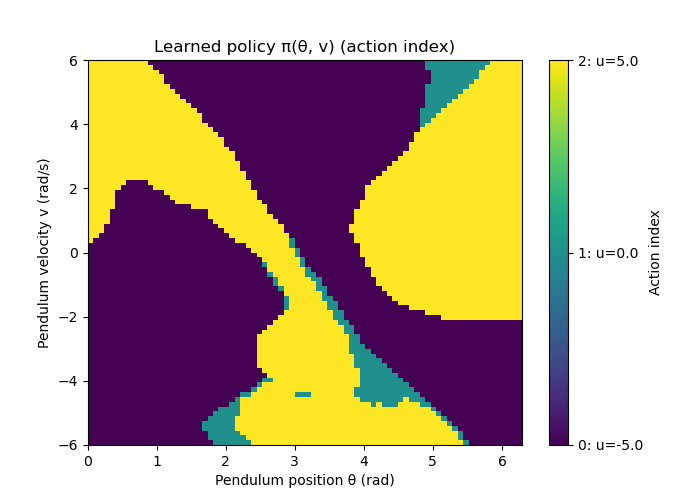

In [20]:
# Cell 10: plot the learned policy pi(theta, v)

plt.figure(figsize=(7, 5))

extent = [theta_min, theta_max, v_min, v_max]

# We plot the action index (0, 1, 2) as an image.
# Later in the colorbar ticks we will map them to the actual control values.
im = plt.imshow(
    policy_index_grid,
    origin="lower",
    extent=extent,
    aspect="auto",
    interpolation="nearest"
)

cbar = plt.colorbar(im)
cbar.set_label("Action index")
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels([f"{i}: u={u}" for i, u in enumerate(possible_controls)])

plt.xlabel("Pendulum position θ (rad)")
plt.ylabel("Pendulum velocity v (rad/s)")
plt.title("Learned policy π(θ, v) (action index)")

# Save figure
plt.savefig("policy_map.png", dpi=300, bbox_inches="tight")
plt.show()
